# Karate

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

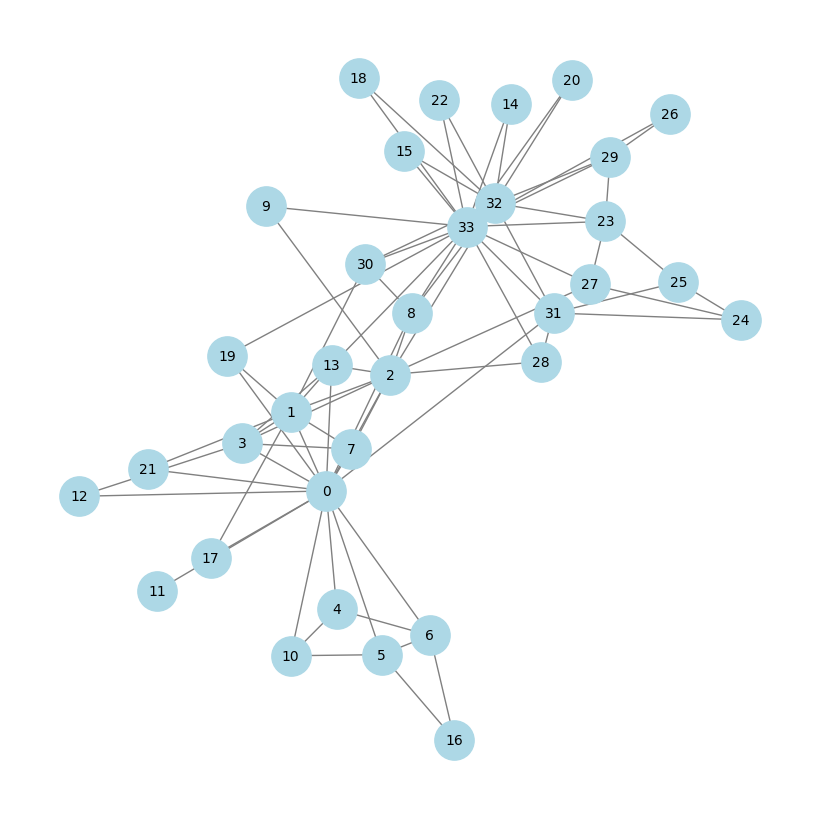

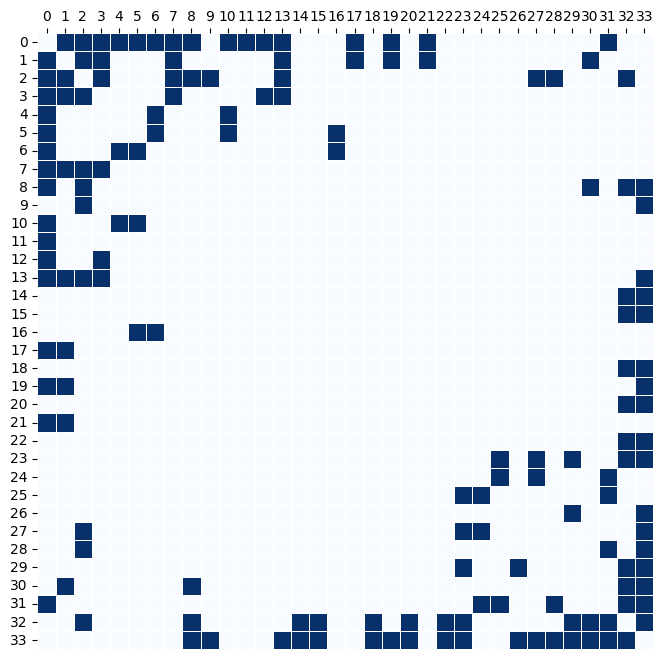

In [2]:
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=10)
plt.show()
Y = nx.to_numpy_array(G, dtype=float)
Y = (Y > 0).astype(int)

plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=10)
plt.show()

In [3]:
seed_MAP = 42
diam = 20.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 20000
n_sim_iv = 2000
n_iter_cv = 2000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R1_p.pkl")

#### Without weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R1_c.pkl")

### Model $\mathbb{R}^2$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [02:10<00:00, 153.53it/s, logpost=-74.4791, loglik=-72.4271, logprior=-2.0521, patience=0] 



Best log-posterior: -74.4791


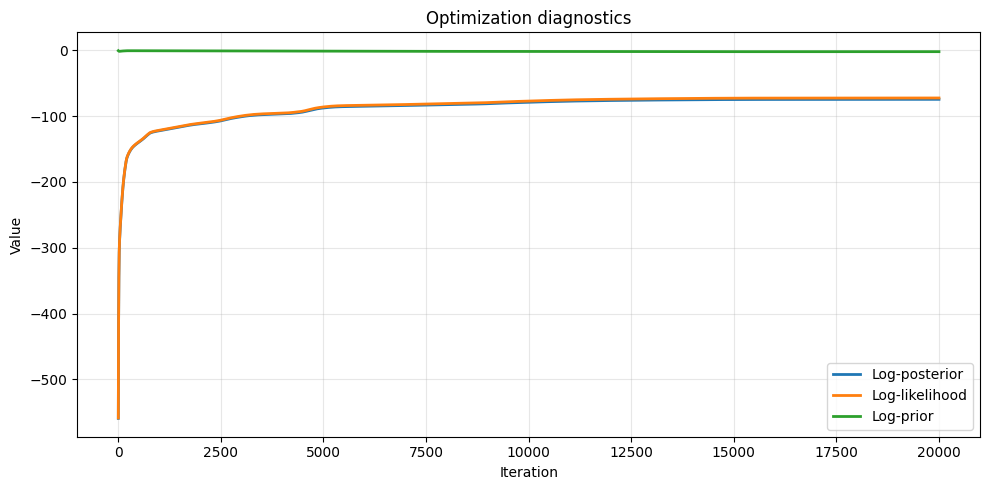

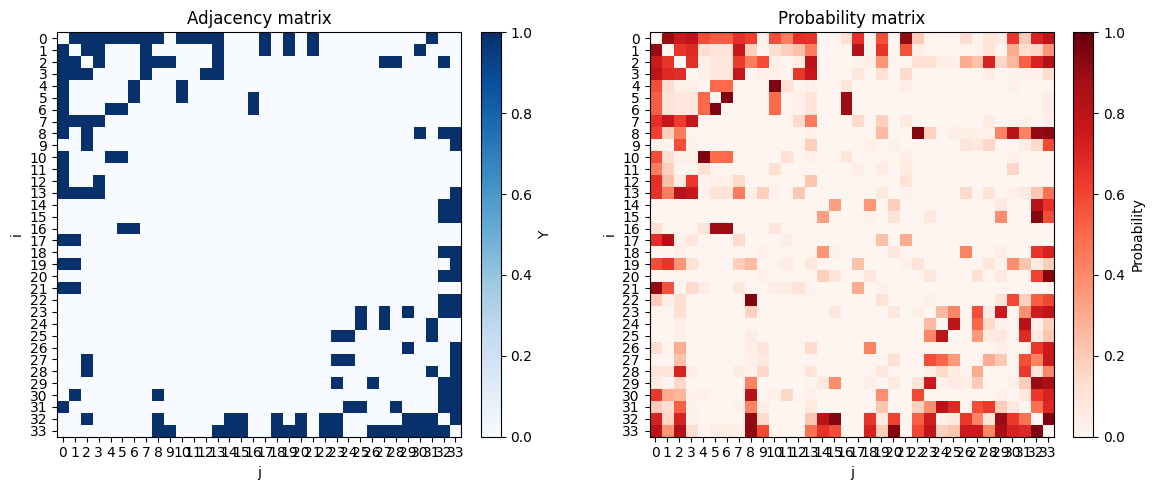

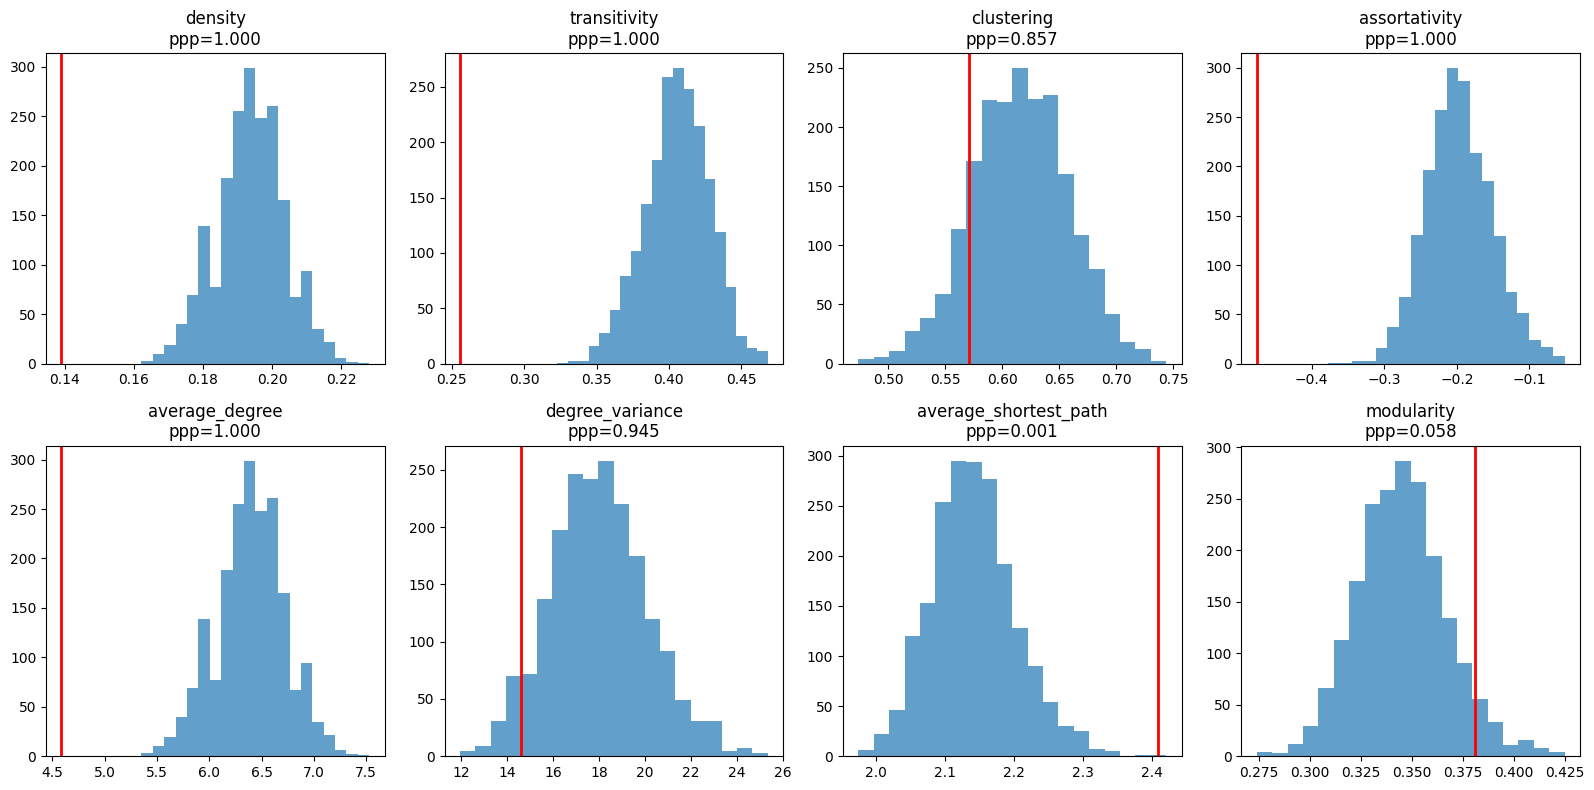

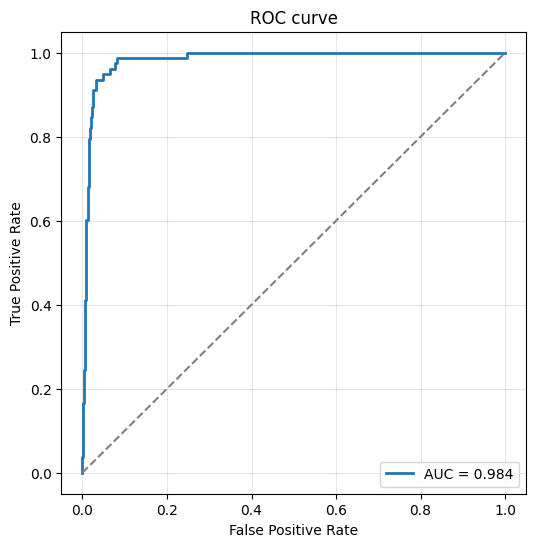

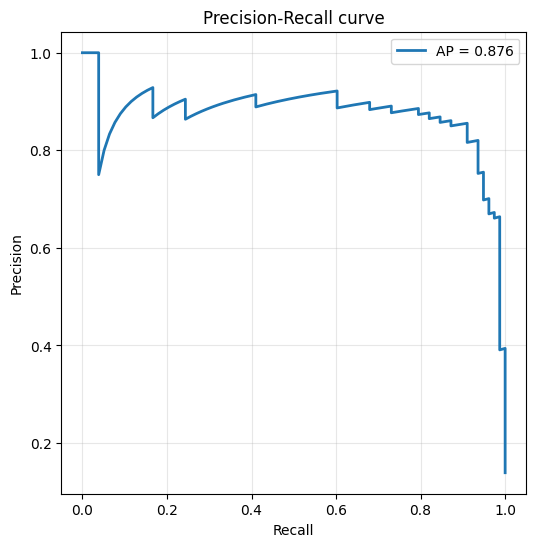

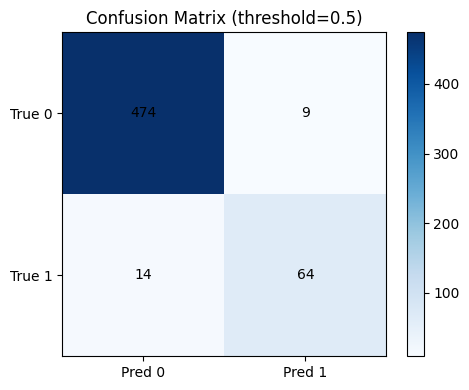

MAP: 100%|██████████| 2000/2000 [00:35<00:00, 56.30it/s, logpost=-58.7234, loglik=-56.6251, logprior=-2.0984, patience=0] 


{'mean_auc': 0.8764724515846964, 'std_auc': 0.022637405494798733, 'min_auc': np.float64(0.8430458430458432), 'max_auc': np.float64(0.9081632653061225), 'n_folds': 5}


In [4]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R2_p.pkl")

#### Without weigths

In [ ]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R2_c.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### With weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S1_p.pkl")

#### Without weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S1_c.pkl")

### Model $\mathbb{S}^2$

#### With weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S2_p.pkl")

#### Without weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S2_c.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H1_p.pkl")

#### Without weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H1_c.pkl")

### Model $\mathbb{H}^2$

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=0.1*lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.1*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H2_p.pkl")

In [ ]:


Z = np.array(model.inferred["MAP"]["final_params"]["Z"])
xi = np.array(model.inferred["MAP"]["final_params"]["xi"])

R = geometry.R

# malla del hiperboloide
x = np.linspace(-diam/2, diam/2, 200)
y = np.linspace(-diam/2, diam/2, 200)

X, Y = np.meshgrid(x, y)
T = np.sqrt(R**2 + X**2 + Y**2)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# hiperboloide
ax.plot_surface(
    X,
    Y,
    T,
    alpha=0.1,
    linewidth=0,
    color="lightgray"
)

# embedding coloreado por xi
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    Z[:, 2],
    c=xi,
    cmap="viridis",
    s=120,
    edgecolors="black",
    alpha=0.9
)

# etiquetas
for i, (x_i, y_i, t_i) in enumerate(Z):
    ax.text(
        x_i,
        y_i,
        t_i,
        str(i),
        fontsize=9
    )

Y = np.array(model.Y)

for i in range(len(Z)):
    for j in range(i+1, len(Z)):
        if Y[i,j] == 1:
            ax.plot(
                [Z[i,0], Z[j,0]],
                [Z[i,1], Z[j,1]],
                [Z[i,2], Z[j,2]],
                alpha=0.4,
                linewidth=1,
                color="gray"
            )

# colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi_i$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$t$")

plt.tight_layout()
plt.show()

#### Without weights

Multi_start (1)


MAP:   0%|          | 0/20000 [00:00<?, ?it/s]

MAP:   1%|          | 128/20000 [00:02<06:08, 53.88it/s, logpost=-298.4473, loglik=-297.8966, logprior=-0.5507, patience=100] 


[STOP] Early stopping at iter 127 (no improvement in 101 steps)

Best log-posterior: -298.4473


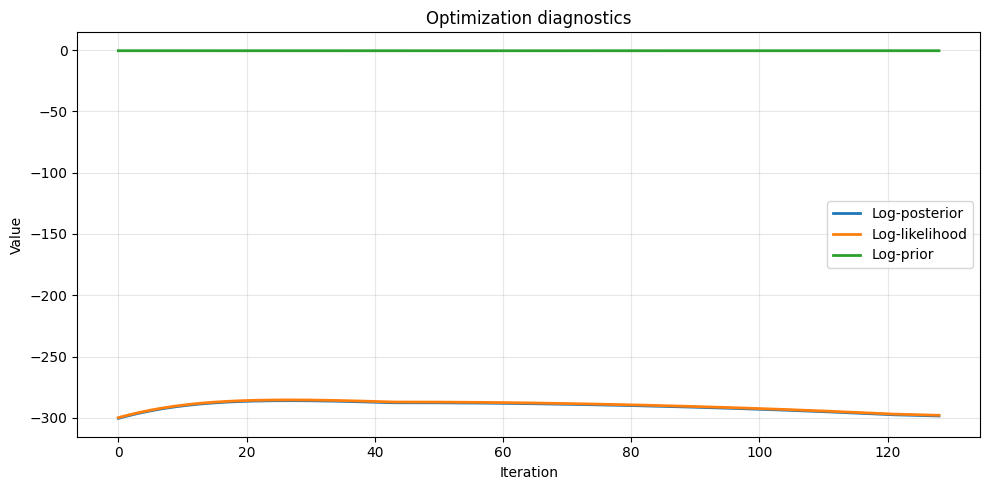

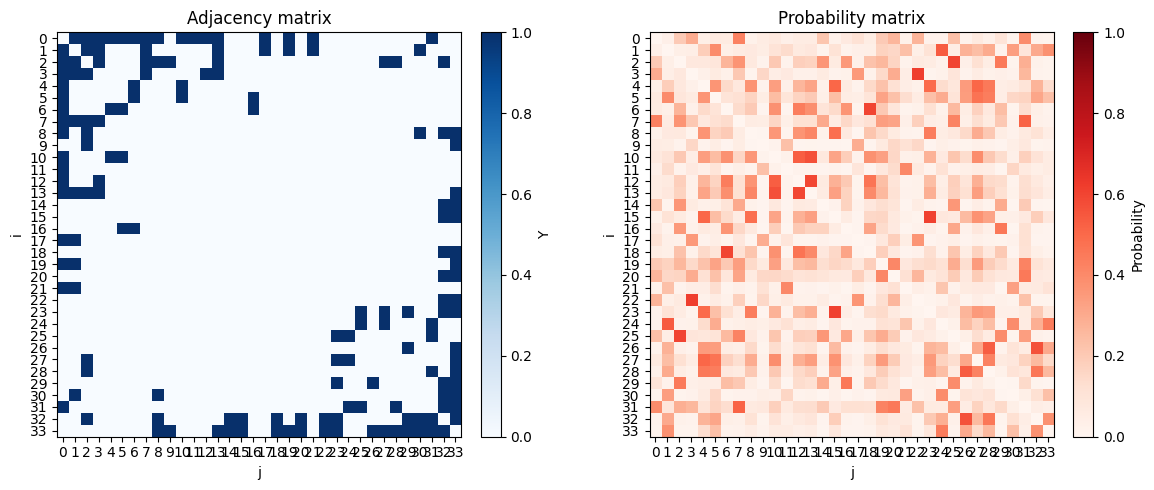

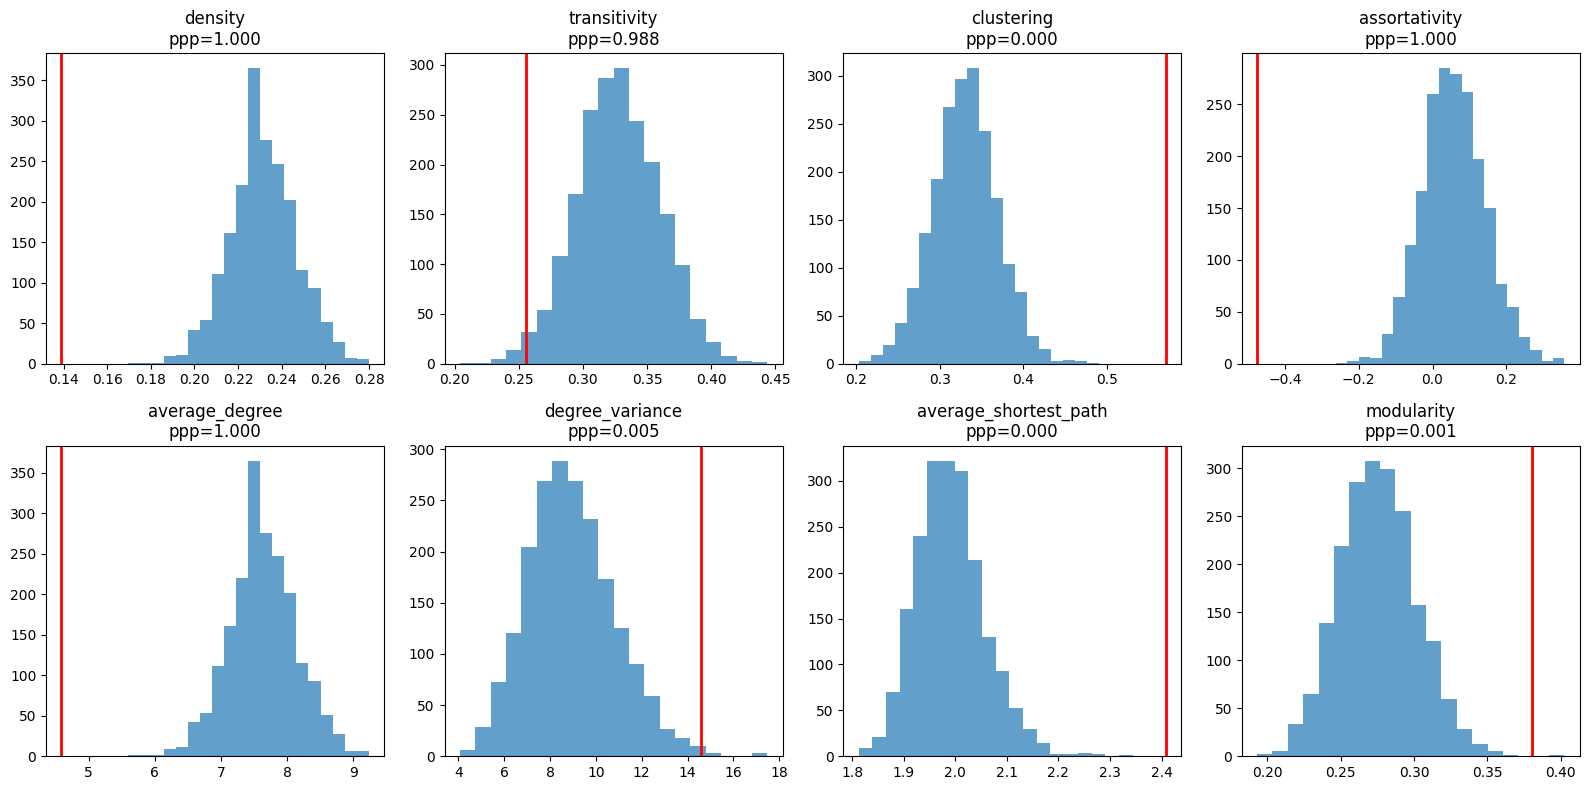

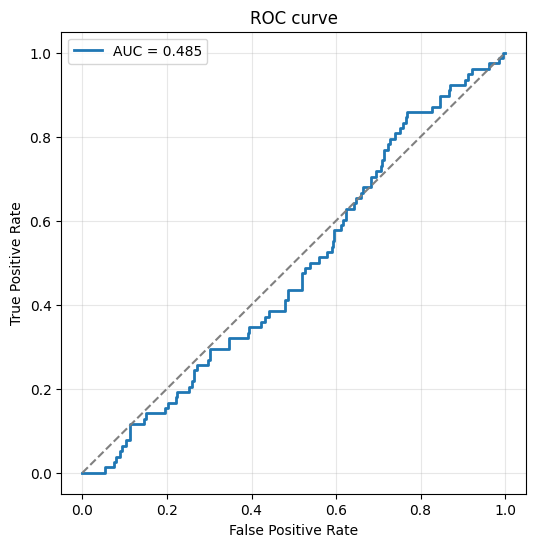

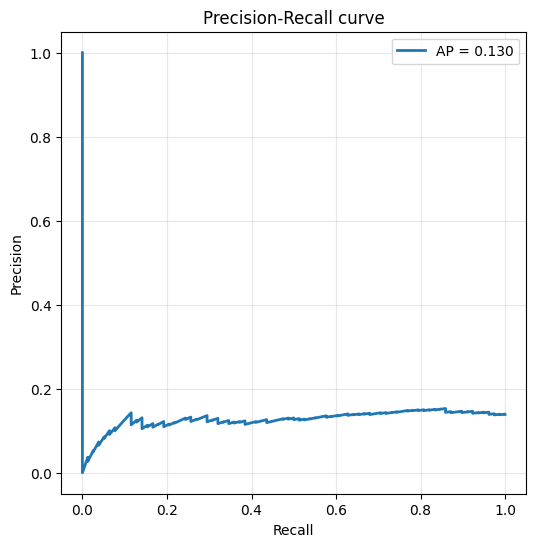

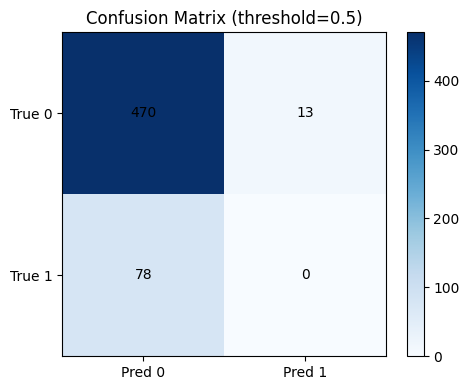

MAP:   2%|▎         | 50/2000 [00:01<00:54, 35.54it/s, logpost=-234.4695, loglik=-233.8866, logprior=-0.5829, patience=49]


{'mean_auc': 0.47520955688302624, 'std_auc': 0.061768320284986876, 'min_auc': np.float64(0.380466472303207), 'max_auc': np.float64(0.5404545454545454), 'n_folds': 5}


In [11]:
geometry = HyperbolicGeometry(d=2, D=2*jnp.pi)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=0.01*lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.1*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H2_c.pkl")

In [12]:
D = np.array(model.inferred["MAP"]["Dmat"])
Y = np.array(model.Y)

idx = np.triu_indices_from(D, k=1)

d_edge = D[idx][Y[idx] == 1]
d_non  = D[idx][Y[idx] == 0]

print(np.mean(d_edge))
print(np.mean(d_non))

3.1471024
3.0670981


In [8]:
import numpy as np
import jax
import jax.numpy as jnp

def test_exp_log_inverse(geom, n_tests=100, seed=0):

    key = jax.random.PRNGKey(seed)

    errors = []

    for k in range(n_tests):

        key, key_z, key_v = jax.random.split(key, 3)

        z = geom.sample_uniform_Z(1, key_z)[0]

        v = jax.random.normal(key_v, shape=z.shape)

        v = geom.project_to_tangent(z, v)

        norm_v = jnp.sqrt(
            jnp.maximum(
                geom._lorentz_inner(v, v),
                1e-12
            )
        )

        v = 0.1 * v / norm_v

        zp = geom.exponential_map(z, v)

        v_rec = geom.logaritmic_map(z, zp)

        err = np.linalg.norm(
            np.array(v_rec - v)
        )

        rel = err / (
            np.linalg.norm(np.array(v)) + 1e-12
        )

        errors.append(rel)

    print("mean relative error =", np.mean(errors))
    print("max relative error  =", np.max(errors))

    return np.array(errors)

test_exp_log_inverse(geom = HyperbolicGeometry(d=2, D=diam))

mean relative error = 0.9829624
max relative error  = 0.98297584


array([0.98296064, 0.9829633 , 0.9829578 , 0.98296964, 0.9829595 ,
       0.9829647 , 0.9829605 , 0.9829678 , 0.9829604 , 0.98296404,
       0.98296255, 0.9829567 , 0.9829614 , 0.98296607, 0.9829641 ,
       0.98296916, 0.9829666 , 0.9829644 , 0.98295444, 0.98296463,
       0.9829665 , 0.9829649 , 0.98296434, 0.9829575 , 0.9829632 ,
       0.98295724, 0.9829637 , 0.98296505, 0.982965  , 0.9829608 ,
       0.9829628 , 0.98296106, 0.982955  , 0.98296934, 0.9829623 ,
       0.98295945, 0.9829619 , 0.9829634 , 0.9829651 , 0.9829652 ,
       0.98296136, 0.98296607, 0.9829564 , 0.9829623 , 0.98295885,
       0.98295885, 0.9829625 , 0.98296696, 0.98296684, 0.9829558 ,
       0.9829687 , 0.9829607 , 0.9829579 , 0.98296267, 0.98295796,
       0.9829665 , 0.98295903, 0.98295975, 0.9829605 , 0.9829613 ,
       0.9829602 , 0.98296106, 0.98296165, 0.9829676 , 0.9829656 ,
       0.98296714, 0.9829631 , 0.9829676 , 0.9829536 , 0.98296154,
       0.9829616 , 0.98295534, 0.98296756, 0.9829623 , 0.98296

In [9]:
def test_hyperboloid_constraint(
    geom,
    n_tests=100,
    seed=0
):

    key = jax.random.PRNGKey(seed)

    errors = []

    for k in range(n_tests):

        key, key_z, key_v = jax.random.split(key, 3)

        z = geom.sample_uniform_Z(1, key_z)[0]

        v = jax.random.normal(key_v, shape=z.shape)
        v = geom.project_to_tangent(z, v)

        zp = geom.exponential_map(z, 0.1*v)

        constraint = (
            geom._lorentz_inner(zp, zp)
            + geom.R**2
        )

        errors.append(
            abs(float(constraint))
        )

    print("mean constraint error =", np.mean(errors))
    print("max constraint error  =", np.max(errors))


test_hyperboloid_constraint(geom = HyperbolicGeometry(d=2, D=diam))

mean constraint error = 0.10708160400390625
max constraint error  = 0.632049560546875


## Results

### Visualization of latent spaces 

### Visualization of probability matrices

### Model statistics

### Internal validation

### External validation